<a href="https://colab.research.google.com/github/jujurdewa/data-science-2026/blob/main/Pertemuan13_Jujur_Dewa_Pamungkas_250401020107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nama : Jujur Dewa Pamungkas

Nim : 250401020107

Prodi : PJJ Informatika

kelas : IF403

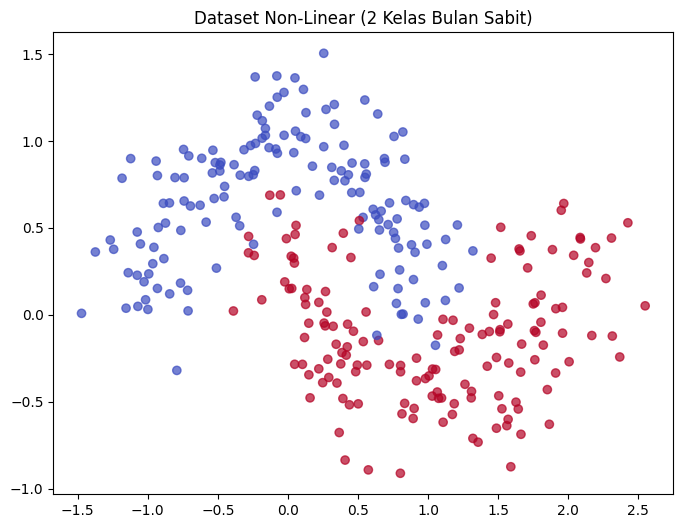

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# Membuat dataset
X, y = make_moons(n_samples=300, noise=0.2, random_state=42)

# Visualisasi
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)
plt.title('Dataset Non-Linear (2 Kelas Bulan Sabit)')
plt.show()

# Penjelasan: Kedua kelas saling melengkung dan bertautan,
# sehingga tidak mungkin dipisahkan dengan satu garis lurus (linear).

In [3]:
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Pisahkan data
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# Bangun Arsitektur Model
model = Sequential([
    Dense(16, activation='relu', input_shape=(2,)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Kompilasi Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# Latih Model
history = model.fit(X_tr, y_tr, epochs=30, validation_split=0.2, verbose=0)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

Akurasi pada data uji: 0.883


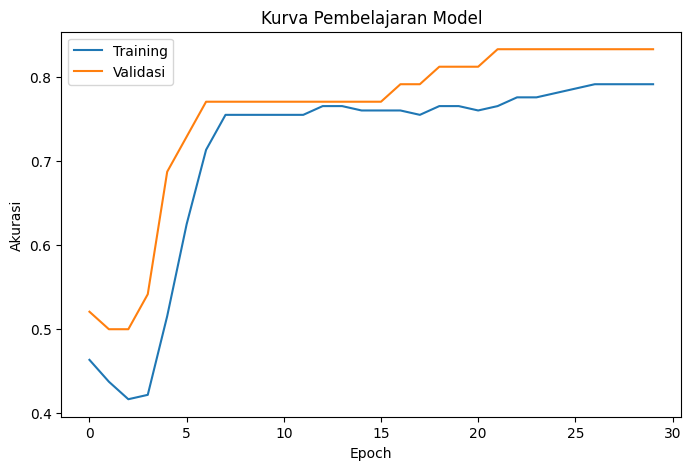

In [4]:
loss, acc = model.evaluate(X_te, y_te, verbose=0)
print(f'Akurasi pada data uji: {acc:.3f}')

# Plot Kurva Belajar
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()
plt.title('Kurva Pembelajaran Model')
plt.show()

**Interpretasi Kurva Belajar:**
Berdasarkan parameter yang kita atur (arsitektur sederhana dengan 30 epochs), umumnya kurva akurasi training dan validasi akan naik dan saling mendekat (bergerak beriringan). Ini adalah pertanda baik bahwa model belajar dengan benar (good fit). Jika kurva training terus naik ke 100% namun kurva validasi malah turun atau menjauh, barulah itu merupakan indikasi overfitting (model hanya menghafal data latih).

In [6]:
# 20 ulasan positif (1) dan 20 ulasan negatif (0)
ulasan = [
    'Barangnya bagus banget, pengiriman cepat', 'Sangat puas, akan beli lagi',
    'Recommended, harga sesuai kualitas', 'Produk original, packing rapi',
    'Mantap, fungsi normal semua', 'Kualitas oke banget', 'Terbaik, respons penjual cepat',
    'Suka banget sama barangnya', 'Sangat membantu dan bermanfaat', 'Luar biasa bagus',
    'Barang sampai dengan aman', 'Desainnya elegan dan mewah', 'Harga murah kualitas sultan',
    'Pasti bakal langganan di sini', 'Bahan tebal dan tidak murahan', 'Cocok banget buat kado',
    'Pengiriman kilat, pesan pagi sore sampai', 'Sesuai dengan gambar dan deskripsi',
    'Nyaman dipakai sehari-hari', 'Fitur lengkap dan mudah digunakan',
    'Kualitas jelek, tidak sesuai deskripsi', 'Kecewa, barang rusak saat sampai',
    'Buruk sekali, tidak sesuai ekspektasi', 'Pengiriman sangat lambat',
    'Penjual tidak responsif', 'Barang cacat, ada bagian yang patah',
    'Menyesal beli di sini', 'Uang melayang, barang tidak berguna',
    'Gampang rusak, baru pakai sehari', 'Beda jauh dengan yang di foto',
    'Bahan tipis dan panas', 'Packaging hancur lebur', 'Layanan pelanggan sangat buruk',
    'Tidak berfungsi sama sekali', 'Rugi banget beli ini', 'Baunya menyengat dan aneh',
    'Ukurannya kekecilan, tidak standar', 'Warnanya pudar, seperti barang bekas',
    'Jangan beli di toko ini', 'Sangat mengecewakan'
]

# Label: 20 angka 1, diikuti 20 angka 0
label = [1]*20 + [0]*20

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_text = tfidf.fit_transform(ulasan)

print('Jumlah kata unik:', len(tfidf.get_feature_names_out()))
print('Contoh kata unik:', tfidf.get_feature_names_out()[:10])

Jumlah kata unik: 115
Contoh kata unik: ['ada' 'akan' 'aman' 'aneh' 'bagian' 'bagus' 'bahan' 'bakal' 'banget'
 'barang']


In [8]:
from sklearn.linear_model import LogisticRegression

# Membagi data latih dan uji teks
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(X_text, label, test_size=0.2, random_state=42)

# Melatih model Logistic Regression
model_sentimen = LogisticRegression()
model_sentimen.fit(Xt_tr, yt_tr)

# Evaluasi Akurasi
akurasi = model_sentimen.score(Xt_te, yt_te)
print(f'Akurasi model sentimen: {akurasi:.3f}')

# Prediksi Kalimat Baru
kalimat_baru = ['Pelayanan sangat memuaskan dan ramah']
# Transformasi teks baru menggunakan tfidf yang sudah di-fit sebelumnya
vektor_baru = tfidf.transform(kalimat_baru)
pred = model_sentimen.predict(vektor_baru)

print('\nHasil Prediksi Kalimat Baru:')
print(f'Teks: "{kalimat_baru[0]}"')
print('Sentimen:', 'Positif' if pred[0] == 1 else 'Negatif')

Akurasi model sentimen: 0.625

Hasil Prediksi Kalimat Baru:
Teks: "Pelayanan sangat memuaskan dan ramah"
Sentimen: Negatif


**KESIMPULAN**

Berdasarkan seluruh rangkaian implementasi yang telah dilakukan, dapat disimpulkan bahwa penerapan teknik machine learning mampu memberikan solusi analitis yang kuat untuk pengambilan keputusan bisnis. Penggunaan algoritma supervised learning seperti Random Forest, khususnya dengan penanganan data yang tidak seimbang (imbalanced data), terbukti efektif dalam memprediksi churn pelanggan sehingga perusahaan dapat mengambil langkah retensi yang proaktif. Selain itu, teknik unsupervised learning melalui K-Means dan Hierarchical Clustering secara konsisten berhasil membagi pelanggan ke dalam tiga segmen utama (Hemat, Menengah, dan Premium), yang memungkinkan personalisasi strategi pemasaran secara lebih akurat dan efisien.

Selanjutnya, eksplorasi terhadap sistem rekomendasi dan pemodelan tingkat lanjut menunjukkan pentingnya pengenalan pola data kompleks. Pendekatan hibrida yang menggabungkan Market Basket Analysis (aturan asosiasi Apriori) dan Content-Based Filtering menghasilkan sistem rekomendasi yang andal untuk strategi cross-selling sekaligus mampu menangani produk baru (cold start problem). Di sisi analitik tingkat lanjut, implementasi Deep Learning melalui Neural Network terbukti krusial untuk memecahkan masalah klasifikasi pada dataset non-linear yang tidak dapat diselesaikan oleh algoritma linier tradisional, dengan evaluasi kurva pembelajaran yang memastikan model tidak mengalami overfitting.

Terakhir, integrasi Natural Language Processing (NLP) berhasil memperluas kapabilitas analisis sistem dari sekadar angka menjadi pemrosesan data teks yang tidak terstruktur. Penggunaan transformasi TF-IDF yang dikombinasikan dengan Logistic Regression memberikan cara yang ringan dan efisien untuk melakukan klasifikasi sentimen pada ulasan produk. Secara keseluruhan, perpaduan dari seluruh langkah pemrosesan data, algoritma prediktif, hingga analisis teks ini membentuk sebuah pipeline Data Science yang komprehensif dan siap diaplikasikan untuk menyelesaikan berbagai tantangan nyata di industri.